# OptoJump Annotation Review
Inspect saved landing / takeoff annotations for a single athlete test.
Set the parameters in **Cell 1**, then run all cells (`Kernel → Restart & Run All`).

In [137]:
# ── Parameters ────────────────────────────────────────────────────────────────
ATHLETE_NAME = "Szymon Jasienczuk"  # must match full_name in the CSV
STUDY_ID = 1
TEST_ID = 1

ANNOTATIONS_CSV = "../data/output/annotations/optojump/ml_training_dataset.csv"  # output of process_video_directory()
VIDEO_DIR = "../data/input/optojump/"  # root that contains study_N/ folders
RECORDING_FPS = 120
VIDEO_FPS = 30

# How many steps to show in the frame-strip panel (None = all)
STEPS_TO_SHOW = None

In [138]:
import os, glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets

plt.rcParams.update(
    {
        "figure.facecolor": "#0f1117",
        "axes.facecolor": "#1a1d27",
        "axes.edgecolor": "#3a3d4d",
        "text.color": "#e0e0e0",
        "axes.labelcolor": "#e0e0e0",
        "xtick.color": "#a0a0b0",
        "ytick.color": "#a0a0b0",
        "grid.color": "#2a2d3a",
        "grid.linewidth": 0.6,
        "font.family": "monospace",
    }
)

GREEN = "#00e676"
RED = "#ff5252"
YELLOW = "#ffd740"
DIM = "#3a3d4d"

In [139]:
def extract_frame(cap: cv2.VideoCapture, frame_idx: int):
    """Seek `cap` to `frame_idx` and return an RGB numpy array, or None on failure."""
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    success, frame = cap.read()
    if not success:
        return None
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def overlay_label(img, label: str, color: tuple) -> np.ndarray:
    """Return a copy of `img` with `label` text drawn in `color` (BGR tuple)."""
    out = img.copy()
    cv2.putText(
        out, label,
        org=(8, 28),
        fontFace=cv2.FONT_HERSHEY_SIMPLEX,
        fontScale=0.7,
        color=color,
        thickness=2,
        lineType=cv2.LINE_AA,
    )
    return out

## 1 · Load annotations

In [140]:
raw = pd.read_csv(ANNOTATIONS_CSV)

# ── resolve which video file belongs to this athlete / study / test ────────
pattern = os.path.join(
    VIDEO_DIR,
    f"study_{STUDY_ID}",
    f"{ATHLETE_NAME.lower().replace(' ', '_')}_{TEST_ID}.mov",
)
matches = glob.glob(pattern)
VIDEO_PATH = matches[0] if matches else None
if VIDEO_PATH is None:
    print(f"⚠  Video not found at: {pattern}")

video_filename = os.path.basename(VIDEO_PATH) if VIDEO_PATH else None

# ── filter continuous-label rows for this video ────────────────────────────
label_df = (
    raw[raw["video_file"] == video_filename].copy()
    if video_filename
    else pd.DataFrame()
)

# ── rebuild event-level annotations from contact/flight boundaries ─────────
# A "touchdown" is the first 'contact' frame after a 'flight' block;
# a "takeoff" is the first 'flight' frame after a 'contact' block.
if not label_df.empty:
    label_df = label_df.sort_values("frame_number").reset_index(drop=True)
    shifted = label_df["label"].shift(1, fill_value="flight")
    td_mask = (label_df["label"] == "contact") & (shifted == "flight")
    to_mask = (label_df["label"] == "flight") & (shifted == "contact")

    td_frames = label_df.loc[td_mask, "frame_number"].tolist()
    to_frames = label_df.loc[to_mask, "frame_number"].tolist()

    event_rows = []
    for i, (td, to) in enumerate(zip(td_frames, to_frames), start=1):
        td_sec = round(td / RECORDING_FPS, 3)
        to_sec = round(to / RECORDING_FPS, 3)
        ct_ms = round((to - td) / RECORDING_FPS * 1000)
        event_rows.extend(
            [
                {
                    "step": i,
                    "event": "touchdown",
                    "frame": td,
                    "time_sec": td_sec,
                    "contact_ms": ct_ms,
                },
                {
                    "step": i,
                    "event": "takeoff",
                    "frame": to,
                    "time_sec": to_sec,
                    "contact_ms": ct_ms,
                },
            ]
        )
    event_df = pd.DataFrame(event_rows)
else:
    event_df = pd.DataFrame()

n_steps = event_df["step"].nunique() if not event_df.empty else 0
n_frames = len(label_df)
n_contact = (label_df["label"] == "contact").sum() if not label_df.empty else 0
n_flight = (label_df["label"] == "flight").sum() if not label_df.empty else 0

print(f"Athlete : {ATHLETE_NAME}   |   Study {STUDY_ID}  ·  Test {TEST_ID}")
print(f"Video   : {video_filename or 'NOT FOUND'}")
print(f"Frames  : {n_frames:,}  ({n_contact:,} contact  /  {n_flight:,} flight)")
print(f"Steps   : {n_steps}")

Athlete : Szymon Jasienczuk   |   Study 1  ·  Test 1
Video   : szymon_jasienczuk_1.mov
Frames  : 59  (7 contact  /  52 flight)
Steps   : 2


In [153]:
label_df

,video_file,video_path,frame_number,label
0,szymon_jasienczuk_1.mov,data/input/optojump/study_1/szymon_jasienczuk_...,2,contact
1,szymon_jasienczuk_1.mov,data/input/optojump/study_1/szymon_jasienczuk_...,3,contact
2,szymon_jasienczuk_1.mov,data/input/optojump/study_1/szymon_jasienczuk_...,4,contact
3,szymon_jasienczuk_1.mov,data/input/optojump/study_1/szymon_jasienczuk_...,5,flight
4,szymon_jasienczuk_1.mov,data/input/optojump/study_1/szymon_jasienczuk_...,6,flight
5,szymon_jasienczuk_1.mov,data/input/optojump/study_1/szymon_jasienczuk_...,7,flight
6,szymon_jasienczuk_1.mov,data/input/optojump/study_1/szymon_jasienczuk_...,8,flight
7,szymon_jasienczuk_1.mov,data/input/optojump/study_1/szymon_jasienczuk_...,9,flight
8,szymon_jasienczuk_1.mov,data/input/optojump/study_1/szymon_jasienczuk_...,10,contact
9,szymon_jasienczuk_1.mov,data/input/optojump/study_1/szymon_jasienczuk_...,11,contact


## 2 · Per-step summary table

In [141]:
if event_df.empty:
    print("No annotations found.")
else:
    td = event_df[event_df["event"] == "touchdown"].set_index("step")
    to = event_df[event_df["event"] == "takeoff"].set_index("step")

    summary = pd.DataFrame(
        {
            "touchdown_frame": td["frame"],
            "touchdown_sec": td["time_sec"],
            "takeoff_frame": to["frame"],
            "takeoff_sec": to["time_sec"],
            "contact_ms": td["contact_ms"],
        }
    ).rename_axis("step")

    display(
        summary.style.format(
            {
                "touchdown_sec": "{:.3f}",
                "takeoff_sec": "{:.3f}",
                "contact_ms": "{:d} ms",
            }
        )
        .background_gradient(subset=["contact_ms"], cmap="YlOrRd")
        .set_caption(f"{ATHLETE_NAME}  —  Study {STUDY_ID}  ·  Test {TEST_ID}")
    )

,touchdown_frame,touchdown_sec,takeoff_frame,takeoff_sec,contact_ms
step,,,,,
1,2,0.017,5,0.042,25 ms
2,10,0.083,14,0.117,33 ms


## 3 · Interactive step scrubber
Use the slider to jump to any step and inspect the surrounding frames in detail.
Requires `ipywidgets` and a running Jupyter kernel.

In [142]:
def show_step(step_num: int, context: int = 1) -> None:
    """Display context frames around touchdown and takeoff for one step."""
    if event_df.empty or VIDEO_PATH is None:
        print("No data.")
        return

    step_events = event_df[event_df["step"] == step_num]
    td_row = step_events[step_events["event"] == "touchdown"]
    to_row = step_events[step_events["event"] == "takeoff"]
    if td_row.empty or to_row.empty:
        print(f"Step {step_num} incomplete.")
        return

    td_f = int(td_row.iloc[0]["frame"])
    to_f = int(to_row.iloc[0]["frame"])
    ct_ms = int(td_row.iloc[0]["contact_ms"])

    cap = cv2.VideoCapture(VIDEO_PATH)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    td_range = [max(0, td_f + i) for i in range(-context, context + 1)]
    to_range = [min(total - 1, to_f + i) for i in range(-context, context + 1)]
    n_cols = len(td_range)

    fig, axes = plt.subplots(2, n_cols, figsize=(10 * n_cols, 15))
    fig.patch.set_facecolor("#0f1117")
    fig.suptitle(
        f"Step {step_num}   |   touchdown f{td_f}  →  takeoff f{to_f}   |   contact {ct_ms} ms",
        color=YELLOW,
        fontsize=11,
        y=1.01,
    )

    for col, (td_fi, to_fi) in enumerate(zip(td_range, to_range)):
        offset = td_fi - td_f
        for row_ax, fidx, base_color, event_label in (
            (0, td_fi, GREEN, "TOUCHDOWN"),
            (1, to_fi, RED, "TAKEOFF"),
        ):
            ax = axes[row_ax][col]
            img = extract_frame(cap, fidx)
            if img is not None:
                color = (0, 230, 118) if base_color == GREEN else (255, 82, 82)
                label = f"{'+' if offset >= 0 else ''}{offset}  f{fidx}"
                ax.imshow(overlay_label(img, label, color))
            ax.axis("off")

            if offset == 0:
                ax.set_title(
                    event_label, color=base_color, fontsize=8, pad=3, fontweight="bold"
                )
                for spine in ax.spines.values():
                    spine.set_visible(True)
                    spine.set_edgecolor(base_color)
                    spine.set_linewidth(2.5)

    cap.release()
    plt.tight_layout()
    plt.show()


if not event_df.empty and n_steps > 0:
    step_slider = widgets.IntSlider(
        value=1,
        min=1,
        max=n_steps,
        description="Step:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="400px"),
    )
    ctx_slider = widgets.IntSlider(
        value=1,
        min=1,
        max=8,
        description="Context frames:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="400px"),
    )
    ui = widgets.VBox([step_slider, ctx_slider])
    out = widgets.interactive_output(
        show_step, {"step_num": step_slider, "context": ctx_slider}
    )
    display(ui, out)
else:
    print("No steps to display.")

Output()

## 4 · Pose kinematics

Load the corresponding YOLO pose data and plot y-position, y-velocity, and y-acceleration for a selected keypoint.
Landing (touchdown) and takeoff moments are marked from the annotations loaded in Cell 1.

In [150]:
import json

from src.gait_analysis.data_cleaning.data_smoothing import smooth_pose_data

# ── resolve pose file path ─────────────────────────────────────────────────
athlete_key = ATHLETE_NAME.lower().replace(" ", "_")
pose_path = os.path.join(
    "../data/output/tuned_yolo/000332/optojump",
    f"study_{STUDY_ID}",
    f"{athlete_key}_{TEST_ID}.json",
)

if not os.path.exists(pose_path):
    print(f"⚠  Pose file not found: {pose_path}")
    smooth_data_opt = None
else:
    with open(pose_path) as f:
        pose_json = json.load(f)

    connections_opt = pose_json["connections"]
    pose_data_raw = pose_json["pose_data"]

    keypoints_opt = list(set(kp for pair in connections_opt for kp in pair))
    anchors_opt = [kp.replace('left_', '').replace('right_', '') for kp in keypoints_opt if any(a in kp for a in ["heel", "big_toe", "knee"])]

    smooth_data_opt = smooth_pose_data(
        pose_data=pose_data_raw,
        keypoints=keypoints_opt,
        anchors=anchors_opt,
        keys_to_exclude={"raw_keypoints"},
        fps=RECORDING_FPS,
        cutoff=4.0,
    )
    smooth_data_opt["frame"] = (
        smooth_data_opt["timestamp_ms"] / 1000 * VIDEO_FPS
    ).astype(int)
    smooth_data_opt = smooth_data_opt.set_index("frame")

    available_parts = sorted(set(
        col[len(side) + 1 : col.rfind("_")]
        for col in smooth_data_opt.columns
        if col.endswith("_y")
        for side in ("left", "right")
        if col.startswith(side + "_")
    ))

    print(f"Loaded: {pose_path}")
    print(f"Frames : {len(smooth_data_opt)}")
    print(f"Parts  : {available_parts}")

Loaded: ../data/output/tuned_yolo/000332/optojump/study_1/szymon_jasienczuk_1.json
Frames : 26
Parts  : ['ankle', 'big_toe', 'heel', 'hip', 'knee', 'shoulder', 'small_toe']


17.0
42.0
83.0
117.0


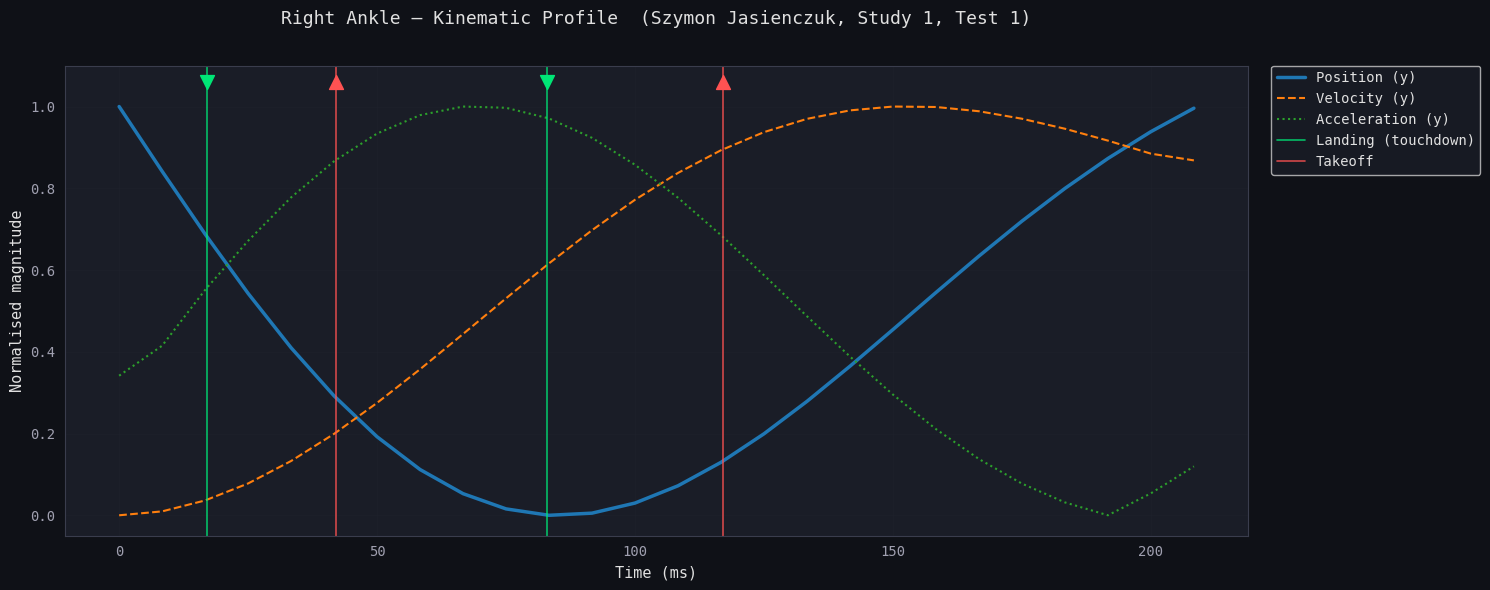

In [157]:
# ── choose your keypoint ──────────────────────────────────────────────────
SIDE = "right"      # "right" or "left"
KEYPOINT = "ankle"  # e.g. "ankle", "heel", "big_toe", "knee", "hip", "shoulder"

# ─────────────────────────────────────────────────────────────────────────
if smooth_data_opt is None or event_df.empty:
    print("Run Cells 1 and the pose-loading cell above first.")
else:
    col = f"{SIDE}_{KEYPOINT}_y"
    if col not in smooth_data_opt.columns:
        print(f"Column '{col}' not found.\nAvailable parts: {available_parts}")
    else:
        dt = 1 / RECORDING_FPS
        pos = smooth_data_opt[col].values * -1
        vel = np.gradient(pos, dt)
        acc = np.gradient(vel, dt)

        def _norm(arr):
            lo, hi = arr.min(), arr.max()
            return (arr - lo) / (hi - lo) if hi > lo else np.zeros_like(arr)

        time_x = smooth_data_opt["timestamp_ms"].values / RECORDING_FPS * VIDEO_FPS

        fig, ax = plt.subplots(figsize=(15, 6))

        ax.plot(time_x, _norm(pos), label="Position (y)",     color="#1f77b4", lw=2.5)
        ax.plot(time_x, _norm(vel), label="Velocity (y)",     color="#ff7f0e", ls="--", lw=1.5)
        ax.plot(time_x, _norm(acc), label="Acceleration (y)", color="#2ca02c", ls=":",  lw=1.5)

        # mark landing / takeoff events
        # event timestamps are computed directly from frame numbers to avoid
        # index-lookup gaps in smooth_data
        td_labeled = to_labeled = False
        for _, row in event_df.iterrows():
            t_ms = row["time_sec"] * 1000
            print(t_ms)
            is_td = row["event"] == "touchdown"
            color = GREEN if is_td else RED
            lbl = None
            if is_td and not td_labeled:
                lbl = "Landing (touchdown)"
                td_labeled = True
            elif not is_td and not to_labeled:
                lbl = "Takeoff"
                to_labeled = True
            ax.axvline(x=t_ms, color=color, alpha=0.8, lw=1.2, label=lbl)
            ax.scatter(
                t_ms, 1.06,
                color=color, marker="v" if is_td else "^",
                s=100, zorder=5, clip_on=False,
            )

        ax.set_title(
            f"{SIDE.capitalize()} {KEYPOINT.capitalize()} — Kinematic Profile  "
            f"({ATHLETE_NAME}, Study {STUDY_ID}, Test {TEST_ID})",
            fontsize=13, pad=30,
        )
        ax.set_xlabel("Time (ms)", fontsize=11)
        ax.set_ylabel("Normalised magnitude", fontsize=11)
        ax.set_ylim(-0.05, 1.10)
        ax.grid(True, alpha=0.15)
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, framealpha=0.8)
        plt.tight_layout()
        plt.show()